In [6]:
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 让负号正常显示

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# 显示设置
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 100

# ====== V5C 终版配置 ======
V5C = {
    'VGSH': 0.09,   # 短债 - 减震器
    'GLDM': 0.06,   # 黄金 - 抗通胀 / 危机对冲
    'DBMF': 0.14,   # 管理期货 - 危机阿尔法
    'VOO':  0.17,   # 美股大盘 - 收益基础
    'VXUS': 0.20,   # 国际股 - 美国例外论对冲
    'SCHD': 0.07,   # 美股息 - 价值因子
    'XLV':  0.09,   # 医疗 - 防守行业
    'AVUV': 0.07,   # 美小盘价值 - 价值+规模因子
    'GOOG': 0.08,   # 个股 - 科技敞口
    'AMLP': 0.03,   # MLP - 能源/通胀对冲
}

# 验证权重和 = 1
print(f"权重总和: {sum(V5C.values()):.4f}")
print(f"资产数量: {len(V5C)}")
print("\nV5C 配置:")
for ticker, weight in sorted(V5C.items(), key=lambda x: -x[1]):
    print(f"  {ticker:>6}: {weight*100:>5.1f}%")

权重总和: 1.0000
资产数量: 10

V5C 配置:
    VXUS:  20.0%
     VOO:  17.0%
    DBMF:  14.0%
    VGSH:   9.0%
     XLV:   9.0%
    GOOG:   8.0%
    SCHD:   7.0%
    AVUV:   7.0%
    GLDM:   6.0%
    AMLP:   3.0%


In [2]:
tickers = list(V5C.keys())

# 选择起点：AVUV 上市日 (2019-09-24)，往后取到今天
# 这是确保所有 10 个 ETF 都有数据的起点
start_date = "2019-10-01"
end_date = datetime.today().strftime("%Y-%m-%d")

print(f"下载 {len(tickers)} 个资产")
print(f"时间范围: {start_date} → {end_date}")
print(f"预计交易日数: ~{int((datetime.now() - datetime(2019,10,1)).days * 252/365)}")

raw = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
prices = raw['Close']

print(f"\n实际数据形状: {prices.shape}")
print(f"日期范围: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"交易日数: {len(prices)}")

# 检查缺失值
missing = prices.isnull().sum()
if missing.any():
    print(f"\n⚠ 缺失值统计:")
    print(missing[missing > 0])
else:
    print(f"\n✅ 所有资产数据完整无缺失")

下载 10 个资产
时间范围: 2019-10-01 → 2026-04-28
预计交易日数: ~1657


[*********************100%***********************]  10 of 10 completed


实际数据形状: (1651, 10)
日期范围: 2019-10-01 → 2026-04-27
交易日数: 1651

✅ 所有资产数据完整无缺失


In [4]:
# ====== 代理资产 - 用于长历史回测 ======
PROXIES = {
    'VOO':  '^SP500TR',      # S&P 500 Total Return Index, 1988+
    'VXUS': 'EFA',           # iShares MSCI EAFE, 2001+ (国际发达市场代理)
    'AVUV': 'VISVX',         # Vanguard Small Cap Value Index Fund, 1998+
    'SCHD': 'DVY',           # iShares Select Dividend, 2003+
    'GLDM': 'GLD',           # SPDR Gold, 2004+
    'DBMF': None,            # 没有公开 ticker；后面我教你下载 SG Trend Index
    'VGSH': 'IEI',           # iShares 3-7 Year Treasury, 2007+ (久期略长但接近)
    'XLV':  'XLV',           # 自己就够长 (1998+)
    'AMLP': None,            # 早期 MLP ETF/ETN 都不够稳定，单独处理
    'GOOG': 'QQQ',           # 大型科技代理 (1999+)，知道这是近似
}

# 下载所有代理资产（更长的历史）
proxy_tickers = [v for v in PROXIES.values() if v is not None]
print(f"下载 {len(proxy_tickers)} 个代理资产")

# 起点：1998 年（包含互联网泡沫）
proxy_start = "1998-01-01"
proxy_raw = yf.download(proxy_tickers, start=proxy_start, end=end_date, auto_adjust=True)
proxy_prices = proxy_raw['Close']

print(f"\n代理数据形状: {proxy_prices.shape}")
print(f"日期范围: {proxy_prices.index[0].date()} → {proxy_prices.index[-1].date()}")
print(f"\n各代理资产数据起点:")
for ticker in proxy_tickers:
    first_valid = proxy_prices[ticker].first_valid_index()
    print(f"  {ticker:>10}: {first_valid.date() if first_valid else 'N/A'}")

下载 8 个代理资产


[*********************100%***********************]  8 of 8 completed


代理数据形状: (7122, 8)
日期范围: 1998-01-02 → 2026-04-27

各代理资产数据起点:
    ^SP500TR: 1998-01-02
         EFA: 2001-08-27
       VISVX: 1998-05-21
         DVY: 2003-11-07
         GLD: 2004-11-18
         IEI: 2007-01-11
         XLV: 1998-12-22
         QQQ: 1999-03-10


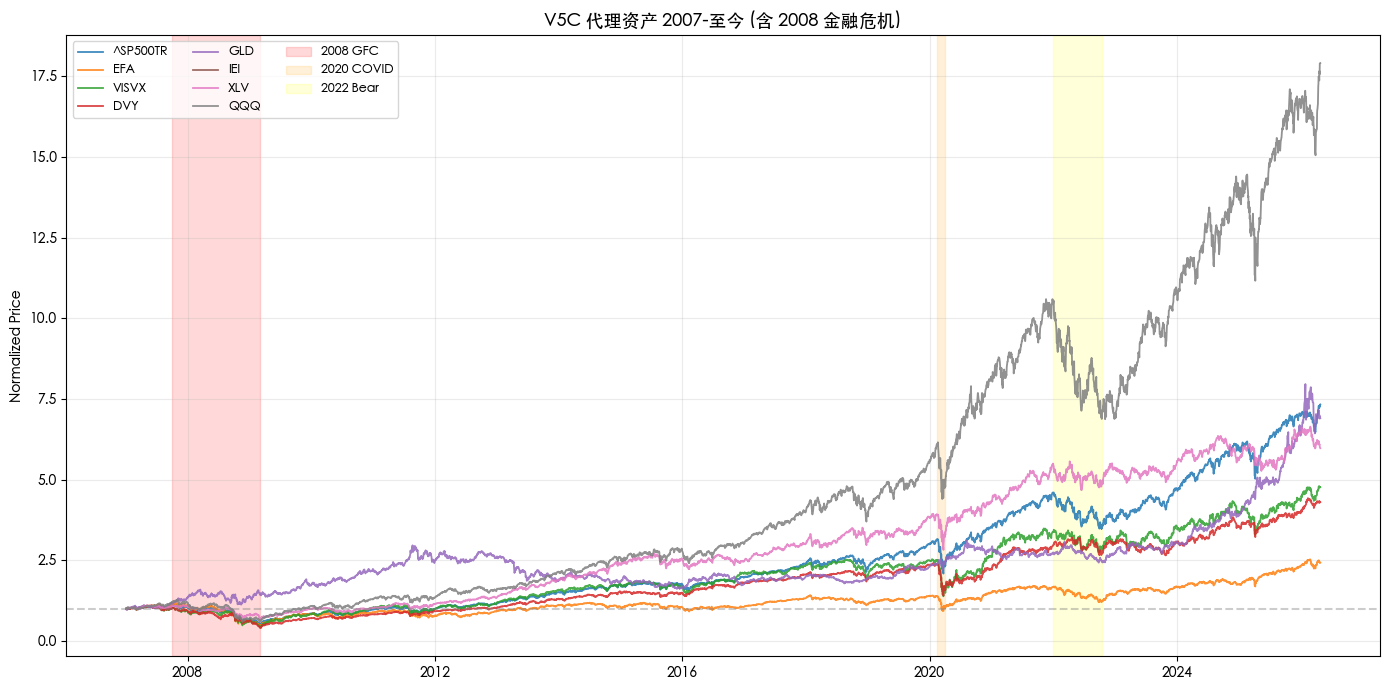

In [7]:
# 选有 2008 年覆盖的代理资产
long_history_tickers = ['^SP500TR', 'EFA', 'VISVX', 'DVY', 'GLD', 'IEI', 'XLV', 'QQQ']
long_prices = proxy_prices[long_history_tickers].dropna(how='all')

# 起点拉到 2007（含 2008 危机）
since_2007 = long_prices[long_prices.index >= '2007-01-01']
normalized_long = since_2007 / since_2007.iloc[0]

fig, ax = plt.subplots(figsize=(14, 7))
for ticker in long_history_tickers:
    if ticker in normalized_long.columns:
        ax.plot(normalized_long.index, normalized_long[ticker], 
                linewidth=1.3, label=ticker, alpha=0.85)

# 标注关键危机事件
ax.axvspan('2007-10-01', '2009-03-01', alpha=0.15, color='red', label='2008 GFC')
ax.axvspan('2020-02-15', '2020-04-01', alpha=0.15, color='orange', label='2020 COVID')
ax.axvspan('2022-01-01', '2022-10-15', alpha=0.15, color='yellow', label='2022 Bear')

ax.set_title('V5C 代理资产 2007-至今 (含 2008 金融危机)', fontsize=13)
ax.set_ylabel('Normalized Price')
ax.axhline(1, color='gray', linestyle='--', alpha=0.4)
ax.legend(loc='upper left', ncol=3, fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

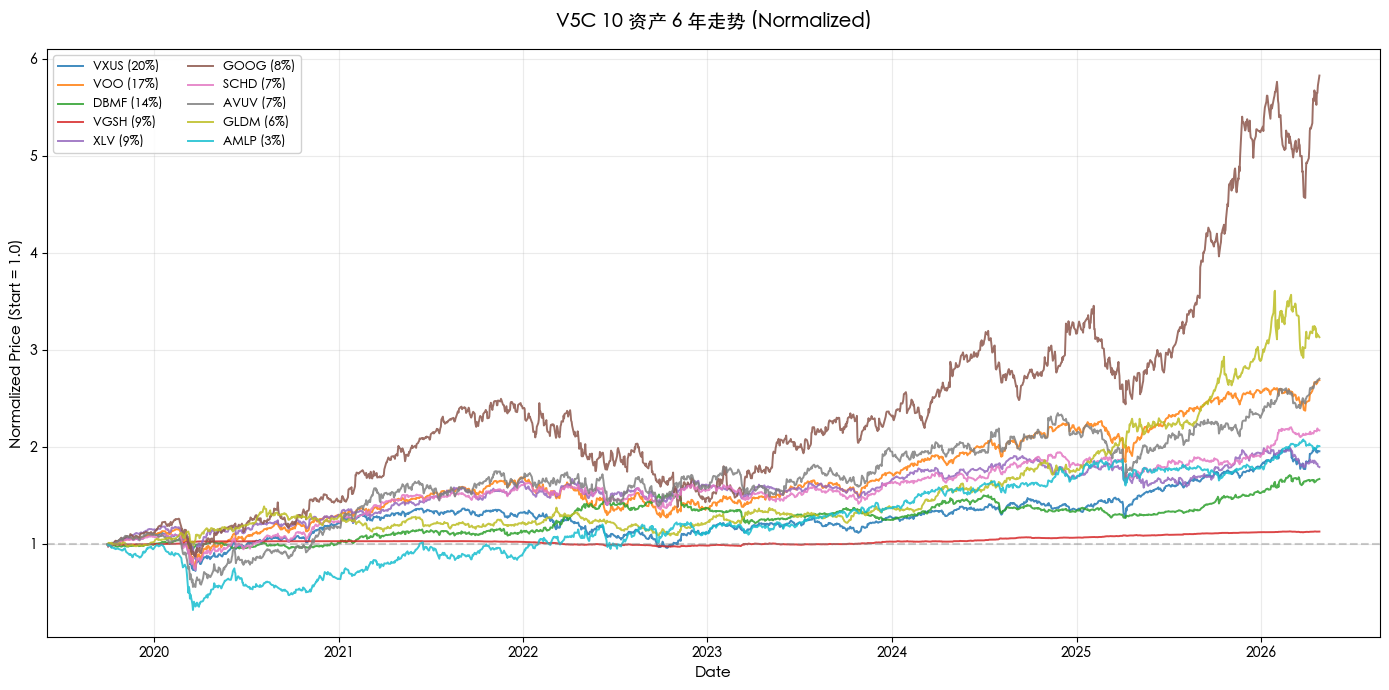

In [8]:
# 归一化：所有资产都从 1.0 起跑
normalized = prices / prices.iloc[0]

# 按 V5C 权重高到低排序，这样图例顺序符合你的认知
sorted_tickers = sorted(V5C.keys(), key=lambda x: -V5C[x])

fig, ax = plt.subplots(figsize=(14, 7))
for ticker in sorted_tickers:
    ax.plot(normalized.index, normalized[ticker], 
            linewidth=1.4, label=f"{ticker} ({V5C[ticker]*100:.0f}%)", alpha=0.85)

ax.set_title('V5C 10 资产 6 年走势 (Normalized)', fontsize=14, pad=15)
ax.set_ylabel('Normalized Price (Start = 1.0)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.axhline(1, color='gray', linestyle='--', alpha=0.4)
ax.legend(loc='upper left', ncol=2, fontsize=9, framealpha=0.9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [9]:
# ====== 个体资产指标计算 ======
returns = prices.pct_change().dropna()

def compute_metrics(ret_series, risk_free=0.03, trading_days=252):
    ret = ret_series.dropna()
    ann_return = ret.mean() * trading_days
    ann_vol = ret.std() * np.sqrt(trading_days)
    sharpe = (ann_return - risk_free) / ann_vol
    
    downside_vol = ret[ret < 0].std() * np.sqrt(trading_days)
    sortino = (ann_return - risk_free) / downside_vol if downside_vol > 0 else np.nan
    
    cum = (1 + ret).cumprod()
    dd = (cum - cum.cummax()) / cum.cummax()
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd < 0 else np.nan
    
    return pd.Series({
        "Ann Return": ann_return,
        "Ann Vol": ann_vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max DD": max_dd,
        "Calmar": calmar
    })

# 应用到所有资产
metrics_table = returns.apply(compute_metrics).T

# 添加 V5C 权重列
metrics_table['V5C 权重'] = pd.Series(V5C)

# 按权重排序
metrics_table = metrics_table.sort_values('V5C 权重', ascending=False)

# 美化显示
display = metrics_table.copy()
display['Ann Return'] = display['Ann Return'].map(lambda x: f"{x*100:.2f}%")
display['Ann Vol']    = display['Ann Vol'].map(lambda x: f"{x*100:.2f}%")
display['Max DD']     = display['Max DD'].map(lambda x: f"{x*100:.2f}%")
display['Sharpe']     = display['Sharpe'].map(lambda x: f"{x:.2f}")
display['Sortino']    = display['Sortino'].map(lambda x: f"{x:.2f}")
display['Calmar']     = display['Calmar'].map(lambda x: f"{x:.2f}")
display['V5C 权重']   = display['V5C 权重'].map(lambda x: f"{x*100:.0f}%")

display

,Ann Return,Ann Vol,Sharpe,Sortino,Max DD,Calmar,V5C 权重
Ticker,,,,,,,
VXUS,12.07%,18.82%,0.48,0.59,-34.93%,0.35,20%
VOO,17.19%,20.25%,0.70,0.85,-33.99%,0.51,17%
DBMF,8.66%,12.48%,0.45,0.57,-20.39%,0.42,14%
VGSH,1.93%,1.79%,-0.60,-0.87,-5.70%,0.34,9%
XLV,10.54%,17.81%,0.42,0.57,-28.40%,0.37,9%
GOOG,31.91%,31.53%,0.92,1.29,-44.60%,0.72,8%
AVUV,19.30%,28.48%,0.57,0.77,-49.42%,0.39,7%
SCHD,13.64%,18.78%,0.57,0.73,-33.37%,0.41,7%
GLDM,19.03%,17.67%,0.91,1.17,-21.63%,0.88,6%


## 4. 相关性矩阵：V5C 10资产之间的关系

相关性矩阵（按 V5C 权重排序）：

Ticker    VXUS     VOO    DBMF    VGSH     XLV    GOOG    SCHD    AVUV   GLDM  \
Ticker                                                                          
VXUS    1.0000  0.8600  0.2000 -0.0300  0.6700  0.5900  0.7800  0.7700 0.2700   
VOO     0.8600  1.0000  0.1900 -0.0900  0.7800  0.7200  0.8600  0.7900 0.1200   
DBMF    0.2000  0.1900  1.0000 -0.3700  0.1100  0.1400  0.1500  0.2000 0.1900   
VGSH   -0.0300 -0.0900 -0.3700  1.0000 -0.0200 -0.0200 -0.1000 -0.1300 0.2900   
XLV     0.6700  0.7800  0.1100 -0.0200  1.0000  0.4800  0.7900  0.5800 0.1100   
GOOG    0.5900  0.7200  0.1400 -0.0200  0.4800  1.0000  0.5000  0.4700 0.1000   
SCHD    0.7800  0.8600  0.1500 -0.1000  0.7900  0.5000  1.0000  0.8500 0.0900   
AVUV    0.7700  0.7900  0.2000 -0.1300  0.5800  0.4700  0.8500  1.0000 0.0800   
GLDM    0.2700  0.1200  0.1900  0.2900  0.1100  0.1000  0.0900  0.0800 1.0000   
AMLP    0.5600  0.5300  0.2300 -0.0900  0.3900  0.3100  0.5800  0.6700 0.0700   

Ticker 

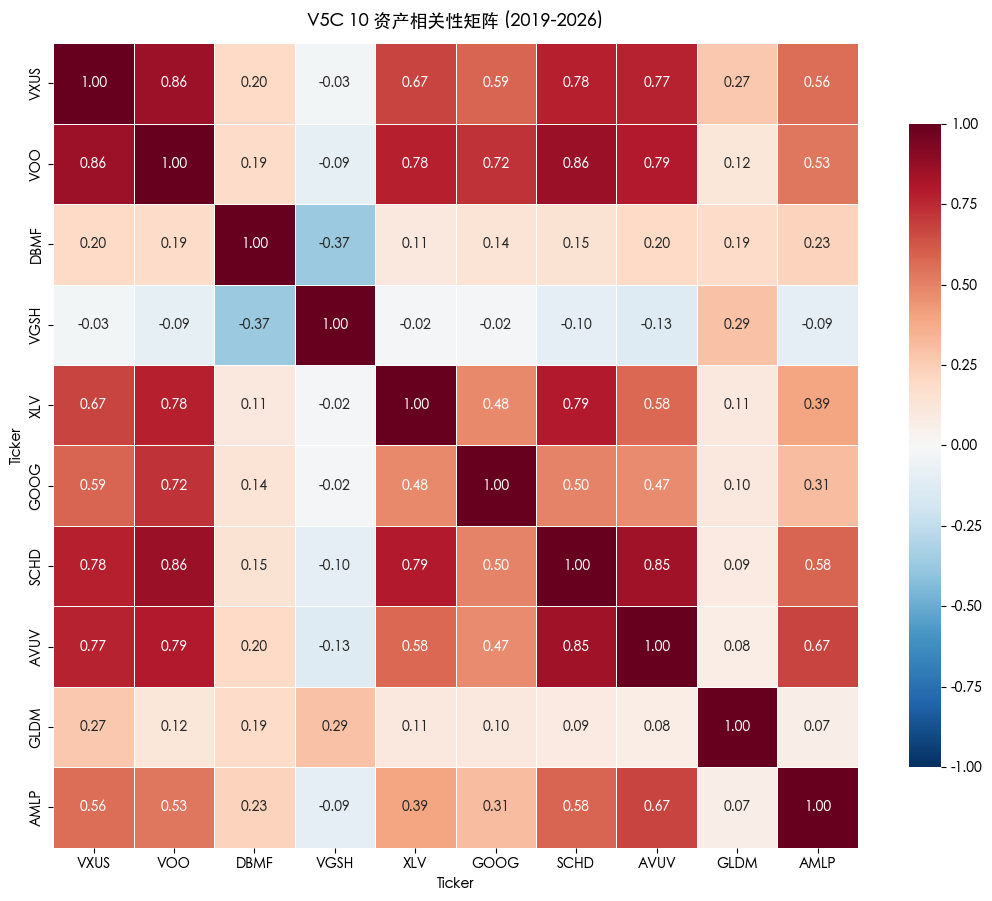

In [10]:
# 计算相关性矩阵
corr_matrix = returns.corr()

# 按 V5C 权重排序（读起来更直观）
ordered_tickers = sorted(V5C.keys(), key=lambda x: -V5C[x])
corr_ordered = corr_matrix.loc[ordered_tickers, ordered_tickers]

print("相关性矩阵（按 V5C 权重排序）：\n")
print(corr_ordered.round(2))

# 画热图
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_ordered,
            annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title('V5C 10 资产相关性矩阵 (2019-2026)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

## 5.构建V5C组合 VS 3个对照组

In [11]:
# === V5C 组合 ===
# 按 V5C 权重加权每个资产的日收益率
weights_array = np.array([V5C[t] for t in returns.columns])
v5c_returns = (returns * weights_array).sum(axis=1)
v5c_cum = (1 + v5c_returns).cumprod()

# === 基准 1: 100% VOO（最简单的"指数化"方案）===
voo_only = returns['VOO']
voo_cum = (1 + voo_only).cumprod()

# === 基准 2: 60/40 (60% VOO + 40% VGSH) ===
# 这是经典的"60/40 股债组合"，但用 VGSH 代替传统债
sixty_forty = 0.6 * returns['VOO'] + 0.4 * returns['VGSH']
sf_cum = (1 + sixty_forty).cumprod()

# === 基准 3: 等权重 10 资产（"傻瓜分散"）===
equal_weights = np.array([0.1] * 10)
equal_weighted = (returns * equal_weights).sum(axis=1)
ew_cum = (1 + equal_weighted).cumprod()

print(f"V5C 数据点数: {len(v5c_returns)}")
print(f"日期范围: {v5c_returns.index[0].date()} → {v5c_returns.index[-1].date()}")

V5C 数据点数: 1650
日期范围: 2019-10-02 → 2026-04-27


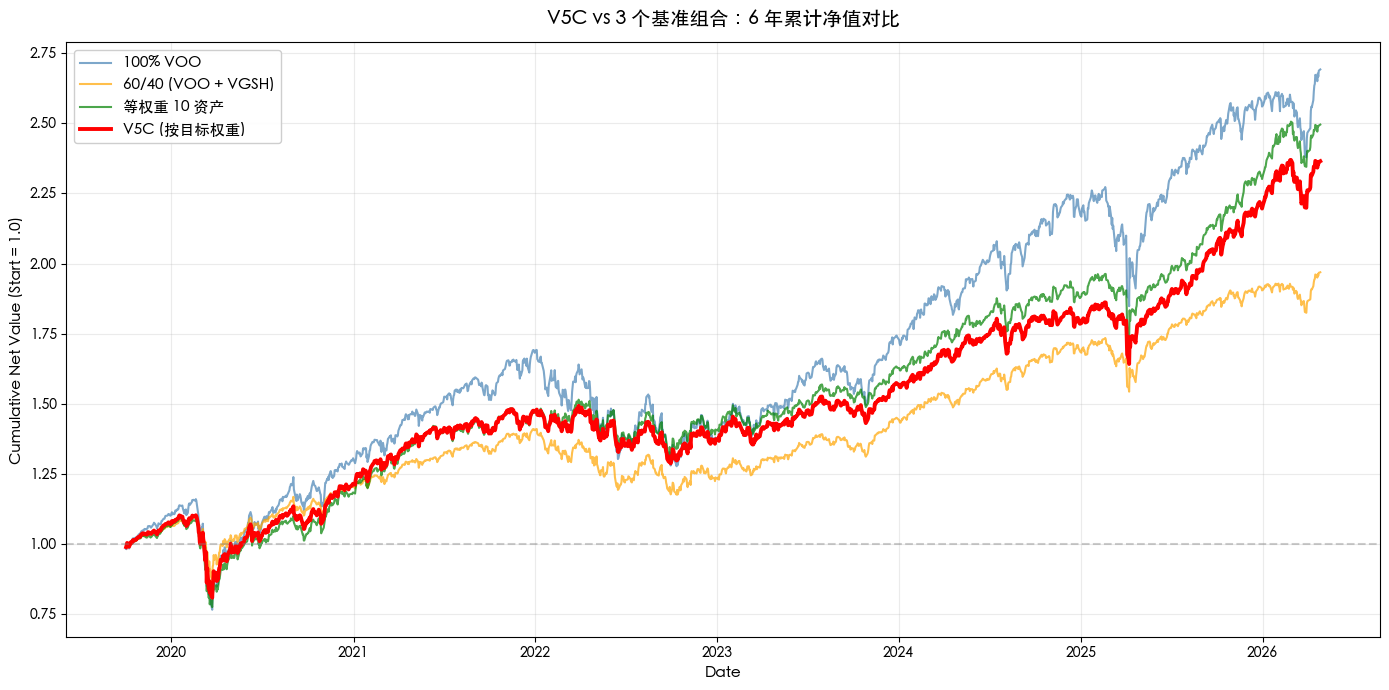

In [12]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(voo_cum.index, voo_cum, label='100% VOO', linewidth=1.5, alpha=0.7, color='steelblue')
ax.plot(sf_cum.index, sf_cum, label='60/40 (VOO + VGSH)', linewidth=1.5, alpha=0.7, color='orange')
ax.plot(ew_cum.index, ew_cum, label='等权重 10 资产', linewidth=1.5, alpha=0.7, color='green')
ax.plot(v5c_cum.index, v5c_cum, label='V5C (按目标权重)', linewidth=2.8, color='red')

ax.axhline(1, color='gray', linestyle='--', alpha=0.4)
ax.set_title('V5C vs 3 个基准组合：6 年累计净值对比', fontsize=14, pad=12)
ax.set_ylabel('Cumulative Net Value (Start = 1.0)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.legend(loc='upper left', fontsize=11, framealpha=0.95)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [13]:
# 用之前定义的 compute_metrics 函数
comparison = pd.DataFrame({
    'V5C': compute_metrics(v5c_returns),
    '100% VOO': compute_metrics(voo_only),
    '60/40': compute_metrics(sixty_forty),
    '等权重': compute_metrics(equal_weighted)
}).T

# 美化
display = comparison.copy()
display['Ann Return'] = display['Ann Return'].map(lambda x: f"{x*100:.2f}%")
display['Ann Vol']    = display['Ann Vol'].map(lambda x: f"{x*100:.2f}%")
display['Max DD']     = display['Max DD'].map(lambda x: f"{x*100:.2f}%")
display['Sharpe']     = display['Sharpe'].map(lambda x: f"{x:.2f}")
display['Sortino']    = display['Sortino'].map(lambda x: f"{x:.2f}")
display['Calmar']     = display['Calmar'].map(lambda x: f"{x:.2f}")

print("="*70)
print("       V5C vs 3 个基准组合（6 年指标对比）")
print("="*70)
display

       V5C vs 3 个基准组合（6 年指标对比）


,Ann Return,Ann Vol,Sharpe,Sortino,Max DD,Calmar
V5C,14.15%,14.08%,0.79,0.94,-26.68%,0.53
100% VOO,17.19%,20.25%,0.70,0.85,-33.99%,0.51
60/40,11.08%,12.11%,0.67,0.82,-20.73%,0.53
等权重,15.01%,14.38%,0.84,0.97,-29.13%,0.52


## 6. V5C 历史压力测试（用代理数据回到 2007 年）

In [14]:
# === Step 1: 构建 V5C-proxy 组合 ===

# ETF → 代理映射（DBMF 和 AMLP 权重按比例分配给其他）
proxy_map = {
    'VOO':  '^SP500TR',
    'VXUS': 'EFA',
    'AVUV': 'VISVX',
    'SCHD': 'DVY',
    'GLDM': 'GLD',
    'VGSH': 'IEI',
    'XLV':  'XLV',
    'GOOG': 'QQQ',
}

# 计算每个代理的"真实权重"（V5C 原权重 / 8 个可用权重之和）
available_v5c = {ticker: V5C[ticker] for ticker in proxy_map.keys()}
total_available = sum(available_v5c.values())
v5c_proxy_weights = {k: v/total_available for k, v in available_v5c.items()}

print("V5C-proxy 重新分配后的权重：")
print("="*45)
for ticker, w in sorted(v5c_proxy_weights.items(), key=lambda x: -x[1]):
    proxy = proxy_map[ticker]
    print(f"  {ticker:<6} → {proxy:<10}  权重: {w*100:>5.2f}% (原 {V5C[ticker]*100:.0f}%)")
print(f"  {'─'*43}")
print(f"  权重总和: {sum(v5c_proxy_weights.values())*100:.2f}%")
print(f"\n注：DBMF (14%) + AMLP (3%) = 17% 已按比例分配到其他 8 个资产")

V5C-proxy 重新分配后的权重：
  VXUS   → EFA         权重: 24.10% (原 20%)
  VOO    → ^SP500TR    权重: 20.48% (原 17%)
  VGSH   → IEI         权重: 10.84% (原 9%)
  XLV    → XLV         权重: 10.84% (原 9%)
  GOOG   → QQQ         权重:  9.64% (原 8%)
  AVUV   → VISVX       权重:  8.43% (原 7%)
  SCHD   → DVY         权重:  8.43% (原 7%)
  GLDM   → GLD         权重:  7.23% (原 6%)
  ───────────────────────────────────────────
  权重总和: 100.00%

注：DBMF (14%) + AMLP (3%) = 17% 已按比例分配到其他 8 个资产


In [15]:
# === Step 2: 计算 V5C-proxy 的每日加权收益 ===

# 用之前下载的 proxy_prices
proxy_returns = proxy_prices.pct_change().dropna(how='all')

# 构建 V5C-proxy 收益序列
v5c_proxy_returns = pd.Series(0.0, index=proxy_returns.index)
for ticker, proxy_ticker in proxy_map.items():
    weight = v5c_proxy_weights[ticker]
    v5c_proxy_returns += weight * proxy_returns[proxy_ticker].fillna(0)

# 只保留所有代理都有数据的日期
valid_dates = proxy_returns[list(proxy_map.values())].dropna().index
v5c_proxy_returns = v5c_proxy_returns.loc[valid_dates]

print(f"\nV5C-proxy 数据范围: {v5c_proxy_returns.index[0].date()} → {v5c_proxy_returns.index[-1].date()}")
print(f"交易日数: {len(v5c_proxy_returns)}")


V5C-proxy 数据范围: 2007-01-12 → 2026-04-27
交易日数: 4852


In [16]:
# === Step 3: 圈定 GFC 时间窗口 ===

gfc_start = '2007-10-09'  # 2007 年 S&P 500 历史峰值
gfc_window_end = '2013-04-01'  # 完全恢复后一段时间

# V5C-proxy 在 GFC 期间
v5c_gfc = v5c_proxy_returns[(v5c_proxy_returns.index >= gfc_start) & 
                              (v5c_proxy_returns.index <= gfc_window_end)]
voo_gfc = proxy_returns['^SP500TR'][(proxy_returns.index >= gfc_start) & 
                                       (proxy_returns.index <= gfc_window_end)]

# 累计净值（从 1.0 起跑）
v5c_gfc_cum = (1 + v5c_gfc).cumprod()
voo_gfc_cum = (1 + voo_gfc).cumprod()

# 计算回撤序列
def get_drawdown_series(cum_returns):
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    return drawdown

v5c_gfc_dd = get_drawdown_series(v5c_gfc_cum)
voo_gfc_dd = get_drawdown_series(voo_gfc_cum)

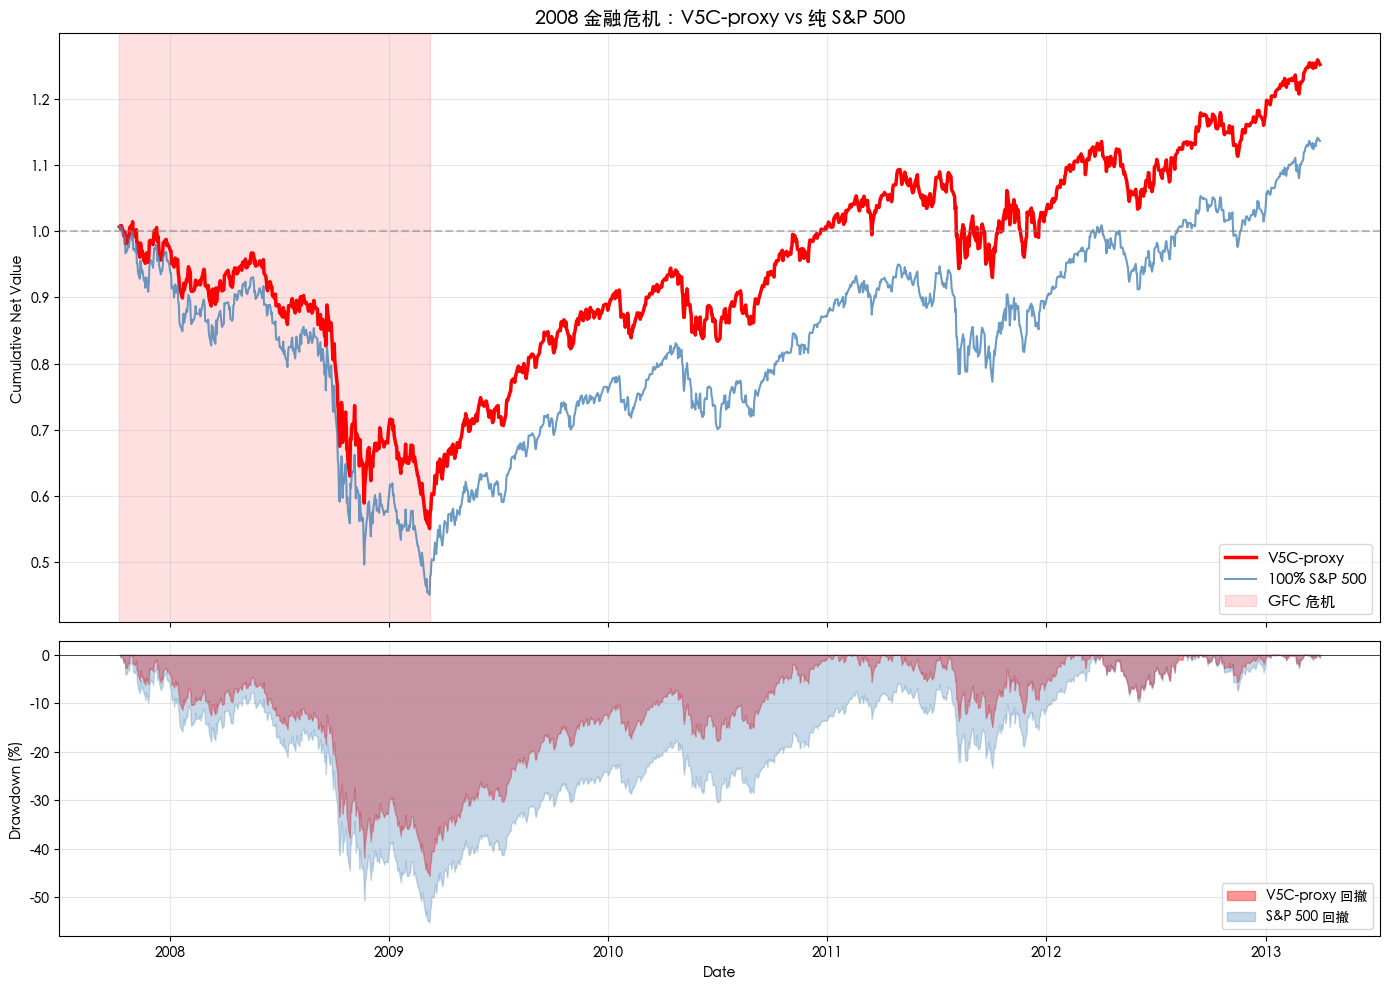

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

# 上图：累计净值
axes[0].plot(v5c_gfc_cum.index, v5c_gfc_cum, 
             label='V5C-proxy', linewidth=2.5, color='red')
axes[0].plot(voo_gfc_cum.index, voo_gfc_cum, 
             label='100% S&P 500', linewidth=1.5, color='steelblue', alpha=0.8)
axes[0].axhline(1, color='gray', linestyle='--', alpha=0.5)
axes[0].axvspan(pd.Timestamp('2007-10-09'), pd.Timestamp('2009-03-09'), 
                alpha=0.12, color='red', label='GFC 危机')
axes[0].set_title('2008 金融危机：V5C-proxy vs 纯 S&P 500', fontsize=14)
axes[0].set_ylabel('Cumulative Net Value')
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(alpha=0.3)

# 下图：回撤
axes[1].fill_between(v5c_gfc_dd.index, v5c_gfc_dd*100, 0, 
                      color='red', alpha=0.4, label='V5C-proxy 回撤')
axes[1].fill_between(voo_gfc_dd.index, voo_gfc_dd*100, 0, 
                      color='steelblue', alpha=0.3, label='S&P 500 回撤')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_xlabel('Date')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# === Step 5: 计算 GFC 期间的关键指标 ===

def crisis_stats(returns, name):
    cum = (1 + returns).cumprod()
    running_max = cum.cummax()
    dd = (cum - running_max) / running_max
    
    max_dd = dd.min()
    max_dd_date = dd.idxmin()
    
    # 起点峰值时间
    peak_value = running_max.loc[max_dd_date]
    peak_date = cum[cum == peak_value].index[0] if (cum == peak_value).any() else cum.index[0]
    
    # 恢复时间：从最低点开始，何时再次达到原峰值
    after_bottom = cum[cum.index >= max_dd_date]
    recovered = after_bottom[after_bottom >= peak_value]
    
    if len(recovered) > 0:
        recovery_date = recovered.index[0]
        peak_to_trough_days = (max_dd_date - peak_date).days
        trough_to_recovery_days = (recovery_date - max_dd_date).days
        peak_to_recovery_days = (recovery_date - peak_date).days
    else:
        recovery_date = None
        peak_to_trough_days = (max_dd_date - peak_date).days
        trough_to_recovery_days = None
        peak_to_recovery_days = None
    
    return {
        'name': name,
        'peak_date': peak_date,
        'trough_date': max_dd_date,
        'recovery_date': recovery_date,
        'max_drawdown': max_dd,
        'peak_to_trough_days': peak_to_trough_days,
        'trough_to_recovery_days': trough_to_recovery_days,
        'peak_to_recovery_days': peak_to_recovery_days,
    }

v5c_stats = crisis_stats(v5c_gfc, 'V5C-proxy')
voo_stats = crisis_stats(voo_gfc, 'S&P 500')

# 打印对比
print("="*65)
print("            2008 金融危机：V5C-proxy vs S&P 500")
print("="*65)
print(f"{'指标':<22} {'V5C-proxy':>20} {'S&P 500':>20}")
print("-"*65)
for label, key in [
    ('峰值日期', 'peak_date'),
    ('谷底日期', 'trough_date'),
    ('恢复日期', 'recovery_date'),
    ('最大回撤 (%)', 'max_drawdown'),
    ('下跌天数', 'peak_to_trough_days'),
    ('恢复天数', 'trough_to_recovery_days'),
    ('总耗时（峰→新峰）', 'peak_to_recovery_days'),
]:
    v5c_val = v5c_stats[key]
    voo_val = voo_stats[key]
    
    if isinstance(v5c_val, pd.Timestamp):
        v5c_str = v5c_val.date().isoformat() if v5c_val else 'N/A'
        voo_str = voo_val.date().isoformat() if voo_val else 'N/A'
    elif key == 'max_drawdown':
        v5c_str = f"{v5c_val*100:.2f}%"
        voo_str = f"{voo_val*100:.2f}%"
    else:
        v5c_str = f"{v5c_val} 天" if v5c_val is not None else 'N/A'
        voo_str = f"{voo_val} 天" if voo_val is not None else 'N/A'
    
    print(f"{label:<22} {v5c_str:>20} {voo_str:>20}")

print("="*65)

            2008 金融危机：V5C-proxy vs S&P 500
指标                                V5C-proxy              S&P 500
-----------------------------------------------------------------
峰值日期                             2007-10-31           2007-10-09
谷底日期                             2009-03-09           2009-03-09
恢复日期                             2011-01-12           2012-04-02
最大回撤 (%)                            -45.66%              -55.25%
下跌天数                                  495 天                517 天
恢复天数                                  674 天               1120 天
总耗时（峰→新峰）                            1169 天               1637 天


## 7. 2020 COVID 危机测试（用真实 V5C 数据）

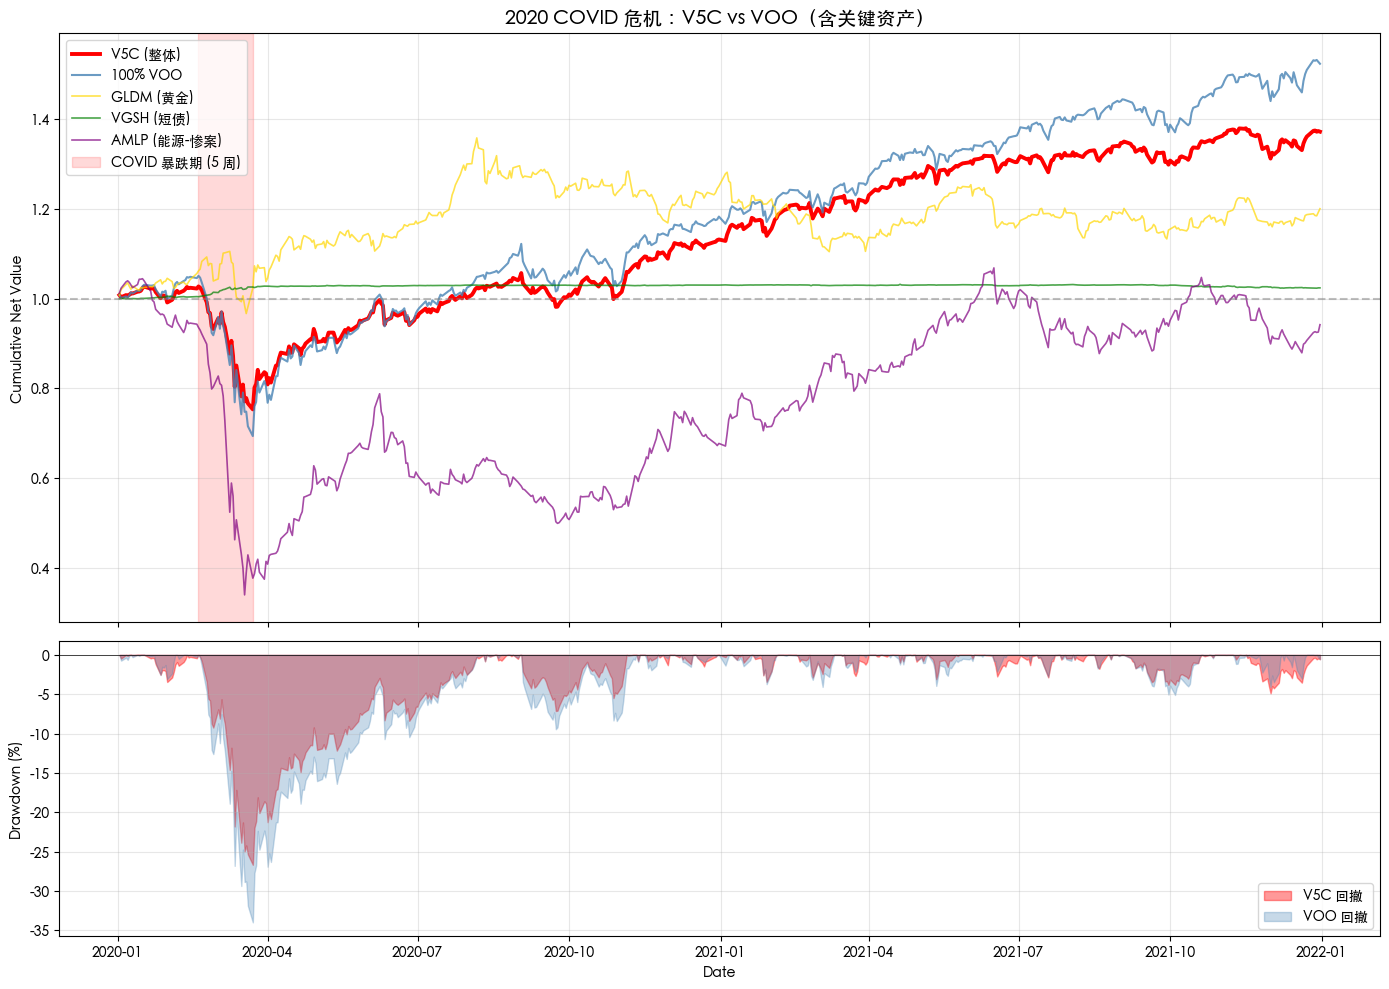

              2020 COVID 危机：V5C vs S&P 500
指标                                      V5C                  VOO
-----------------------------------------------------------------
峰值日期                             2020-02-19           2020-02-19
谷底日期                             2020-03-23           2020-03-23
恢复日期                             2020-08-12           2020-08-10
最大回撤 (%)                            -26.68%              -33.99%
下跌天数                                   33 天                 33 天
恢复天数                                  142 天                140 天
总耗时（峰→新峰）                             175 天                173 天


In [19]:
# === 2020 COVID 测试 ===

# 截取 2020-01-01 到 2021-12-31（看完整暴跌+恢复）
covid_window = (v5c_returns.index >= '2020-01-01') & (v5c_returns.index <= '2021-12-31')

v5c_covid = v5c_returns.loc[covid_window]
voo_covid = returns['VOO'].loc[covid_window]
gldm_covid = returns['GLDM'].loc[covid_window]
vgsh_covid = returns['VGSH'].loc[covid_window]
amlp_covid = returns['AMLP'].loc[covid_window]   # 看 AMLP 在 COVID 多惨

# 累计净值
v5c_covid_cum = (1 + v5c_covid).cumprod()
voo_covid_cum = (1 + voo_covid).cumprod()
gldm_covid_cum = (1 + gldm_covid).cumprod()
vgsh_covid_cum = (1 + vgsh_covid).cumprod()
amlp_covid_cum = (1 + amlp_covid).cumprod()

# 回撤序列
v5c_covid_dd = get_drawdown_series(v5c_covid_cum)
voo_covid_dd = get_drawdown_series(voo_covid_cum)

# === 画图：累计净值 + 回撤 ===
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

# 上图：V5C vs VOO + 关键防御资产单独显示
axes[0].plot(v5c_covid_cum.index, v5c_covid_cum, 
             label='V5C (整体)', linewidth=2.8, color='red')
axes[0].plot(voo_covid_cum.index, voo_covid_cum, 
             label='100% VOO', linewidth=1.5, color='steelblue', alpha=0.8)
axes[0].plot(gldm_covid_cum.index, gldm_covid_cum, 
             label='GLDM (黄金)', linewidth=1.2, color='gold', alpha=0.7)
axes[0].plot(vgsh_covid_cum.index, vgsh_covid_cum, 
             label='VGSH (短债)', linewidth=1.2, color='green', alpha=0.7)
axes[0].plot(amlp_covid_cum.index, amlp_covid_cum, 
             label='AMLP (能源-惨案)', linewidth=1.2, color='purple', alpha=0.7)

axes[0].axhline(1, color='gray', linestyle='--', alpha=0.5)
axes[0].axvspan(pd.Timestamp('2020-02-19'), pd.Timestamp('2020-03-23'), 
                alpha=0.15, color='red', label='COVID 暴跌期 (5 周)')
axes[0].set_title('2020 COVID 危机：V5C vs VOO（含关键资产）', fontsize=14)
axes[0].set_ylabel('Cumulative Net Value')
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(alpha=0.3)

# 下图：回撤
axes[1].fill_between(v5c_covid_dd.index, v5c_covid_dd*100, 0, 
                      color='red', alpha=0.4, label='V5C 回撤')
axes[1].fill_between(voo_covid_dd.index, voo_covid_dd*100, 0, 
                      color='steelblue', alpha=0.3, label='VOO 回撤')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_xlabel('Date')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# === 计算关键统计 ===
v5c_stats_covid = crisis_stats(v5c_covid.loc[:'2021-06-30'], 'V5C')
voo_stats_covid = crisis_stats(voo_covid.loc[:'2021-06-30'], '100% VOO')

print("="*65)
print("              2020 COVID 危机：V5C vs S&P 500")
print("="*65)
print(f"{'指标':<22} {'V5C':>20} {'VOO':>20}")
print("-"*65)
for label, key in [
    ('峰值日期', 'peak_date'),
    ('谷底日期', 'trough_date'),
    ('恢复日期', 'recovery_date'),
    ('最大回撤 (%)', 'max_drawdown'),
    ('下跌天数', 'peak_to_trough_days'),
    ('恢复天数', 'trough_to_recovery_days'),
    ('总耗时（峰→新峰）', 'peak_to_recovery_days'),
]:
    v5c_val = v5c_stats_covid[key]
    voo_val = voo_stats_covid[key]
    
    if isinstance(v5c_val, pd.Timestamp):
        v5c_str = v5c_val.date().isoformat() if v5c_val else 'N/A'
        voo_str = voo_val.date().isoformat() if voo_val else 'N/A'
    elif key == 'max_drawdown':
        v5c_str = f"{v5c_val*100:.2f}%"
        voo_str = f"{voo_val*100:.2f}%"
    else:
        v5c_str = f"{v5c_val} 天" if v5c_val is not None else 'N/A'
        voo_str = f"{voo_val} 天" if voo_val is not None else 'N/A'
    
    print(f"{label:<22} {v5c_str:>20} {voo_str:>20}")

print("="*65)

## 8. 2022 加息熊市测试（用真实 V5C 数据）

In [20]:
# === 2022 加息熊市测试 ===

# 时间窗口：2022.01 - 2024.06（覆盖完整峰→谷→恢复）
bear_start = '2022-01-01'
bear_end = '2024-12-31'

bear_mask = (v5c_returns.index >= bear_start) & (v5c_returns.index <= bear_end)

# 主要组合
v5c_bear = v5c_returns.loc[bear_mask]
voo_bear = returns['VOO'].loc[bear_mask]
# 加上 60/40 基准对比
sixty_forty_bear = (0.6 * returns['VOO'] + 0.4 * returns['VGSH']).loc[bear_mask]

# 关键防御资产单独看
dbmf_bear = returns['DBMF'].loc[bear_mask]
amlp_bear = returns['AMLP'].loc[bear_mask]
gldm_bear = returns['GLDM'].loc[bear_mask]
vgsh_bear = returns['VGSH'].loc[bear_mask]

# 累计净值
v5c_bear_cum = (1 + v5c_bear).cumprod()
voo_bear_cum = (1 + voo_bear).cumprod()
sf_bear_cum = (1 + sixty_forty_bear).cumprod()
dbmf_bear_cum = (1 + dbmf_bear).cumprod()
amlp_bear_cum = (1 + amlp_bear).cumprod()
gldm_bear_cum = (1 + gldm_bear).cumprod()
vgsh_bear_cum = (1 + vgsh_bear).cumprod()

# 回撤序列
v5c_bear_dd = get_drawdown_series(v5c_bear_cum)
voo_bear_dd = get_drawdown_series(voo_bear_cum)
sf_bear_dd = get_drawdown_series(sf_bear_cum)

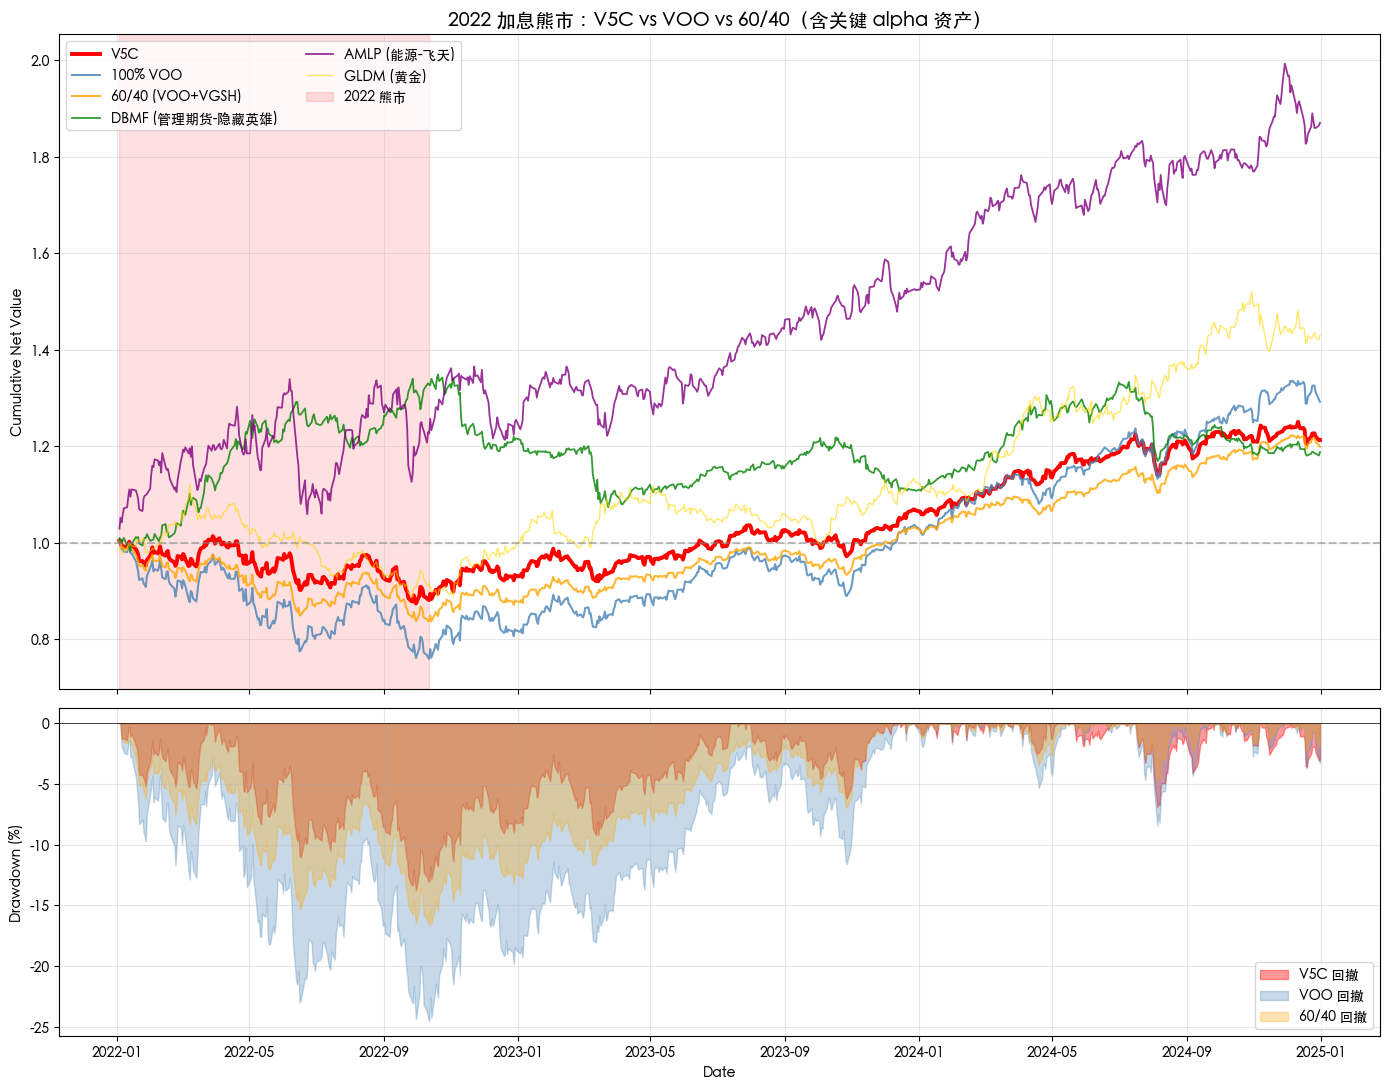

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

# 上图：累计净值（看主组合 + 关键防御资产）
axes[0].plot(v5c_bear_cum.index, v5c_bear_cum, 
             label='V5C', linewidth=2.8, color='red')
axes[0].plot(voo_bear_cum.index, voo_bear_cum, 
             label='100% VOO', linewidth=1.5, color='steelblue', alpha=0.8)
axes[0].plot(sf_bear_cum.index, sf_bear_cum, 
             label='60/40 (VOO+VGSH)', linewidth=1.5, color='orange', alpha=0.8)

# 关键 alpha 资产：DBMF 和 AMLP 在 2022 应该是英雄
axes[0].plot(dbmf_bear_cum.index, dbmf_bear_cum, 
             label='DBMF (管理期货-隐藏英雄)', linewidth=1.3, color='green', alpha=0.8)
axes[0].plot(amlp_bear_cum.index, amlp_bear_cum, 
             label='AMLP (能源-飞天)', linewidth=1.3, color='purple', alpha=0.8)
axes[0].plot(gldm_bear_cum.index, gldm_bear_cum, 
             label='GLDM (黄金)', linewidth=1.0, color='gold', alpha=0.6)

axes[0].axhline(1, color='gray', linestyle='--', alpha=0.5)
axes[0].axvspan(pd.Timestamp('2022-01-03'), pd.Timestamp('2022-10-12'), 
                alpha=0.12, color='red', label='2022 熊市')
axes[0].set_title('2022 加息熊市：V5C vs VOO vs 60/40（含关键 alpha 资产）', fontsize=14)
axes[0].set_ylabel('Cumulative Net Value')
axes[0].legend(loc='upper left', fontsize=10, ncol=2)
axes[0].grid(alpha=0.3)

# 下图：三个组合的回撤
axes[1].fill_between(v5c_bear_dd.index, v5c_bear_dd*100, 0, 
                      color='red', alpha=0.4, label='V5C 回撤')
axes[1].fill_between(voo_bear_dd.index, voo_bear_dd*100, 0, 
                      color='steelblue', alpha=0.3, label='VOO 回撤')
axes[1].fill_between(sf_bear_dd.index, sf_bear_dd*100, 0, 
                      color='orange', alpha=0.3, label='60/40 回撤')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_xlabel('Date')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# 2022 熊市统计
v5c_stats_bear = crisis_stats(v5c_bear, 'V5C')
voo_stats_bear = crisis_stats(voo_bear, 'VOO')
sf_stats_bear = crisis_stats(sixty_forty_bear, '60/40')

print("="*75)
print("              2022 加息熊市：V5C vs VOO vs 60/40")
print("="*75)
print(f"{'指标':<22} {'V5C':>16} {'VOO':>16} {'60/40':>16}")
print("-"*75)
for label, key in [
    ('峰值日期', 'peak_date'),
    ('谷底日期', 'trough_date'),
    ('恢复日期', 'recovery_date'),
    ('最大回撤 (%)', 'max_drawdown'),
    ('下跌天数', 'peak_to_trough_days'),
    ('恢复天数', 'trough_to_recovery_days'),
    ('总耗时', 'peak_to_recovery_days'),
]:
    v5c_val = v5c_stats_bear[key]
    voo_val = voo_stats_bear[key]
    sf_val = sf_stats_bear[key]
    
    if isinstance(v5c_val, pd.Timestamp):
        v5c_str = v5c_val.date().isoformat() if v5c_val else 'N/A'
        voo_str = voo_val.date().isoformat() if voo_val else 'N/A'
        sf_str = sf_val.date().isoformat() if sf_val else 'N/A'
    elif key == 'max_drawdown':
        v5c_str = f"{v5c_val*100:.2f}%"
        voo_str = f"{voo_val*100:.2f}%"
        sf_str = f"{sf_val*100:.2f}%"
    else:
        v5c_str = f"{v5c_val} 天" if v5c_val is not None else 'N/A'
        voo_str = f"{voo_val} 天" if voo_val is not None else 'N/A'
        sf_str = f"{sf_val} 天" if sf_val is not None else 'N/A'
    
    print(f"{label:<22} {v5c_str:>16} {voo_str:>16} {sf_str:>16}")

# 计算 2022 全年（整年表现）
y2022 = (v5c_returns.index >= '2022-01-01') & (v5c_returns.index <= '2022-12-31')

print("\n" + "="*55)
print("           2022 全年表现（关键资产）")
print("="*55)
for ticker in ['VOO', 'VXUS', 'AVUV', 'SCHD', 'XLV', 'GOOG', 'GLDM', 'DBMF', 'AMLP', 'VGSH']:
    annual_return = (1 + returns[ticker].loc[y2022]).prod() - 1
    color_marker = '📈' if annual_return > 0 else '📉'
    print(f"  {color_marker} {ticker:<6}: {annual_return*100:>+7.2f}%")

# V5C 整体 2022
v5c_2022 = (1 + v5c_returns.loc[y2022]).prod() - 1
voo_2022 = (1 + returns['VOO'].loc[y2022]).prod() - 1
sf_2022 = (1 + sixty_forty_bear.loc[y2022.values[bear_mask]]).prod() - 1 if False else None
# Recompute for full 2022
sf_full_2022 = (0.6 * returns['VOO'] + 0.4 * returns['VGSH']).loc[y2022]
sf_2022 = (1 + sf_full_2022).prod() - 1

print("-"*55)
print(f"  🎯 V5C 整体 2022:    {v5c_2022*100:>+7.2f}%")
print(f"  🎯 100% VOO 2022:    {voo_2022*100:>+7.2f}%")
print(f"  🎯 60/40 2022:       {sf_2022*100:>+7.2f}%")
print("="*55)

              2022 加息熊市：V5C vs VOO vs 60/40
指标                                  V5C              VOO            60/40
---------------------------------------------------------------------------
峰值日期                         2022-03-29       2022-01-03       2022-01-04
谷底日期                         2022-09-30       2022-10-12       2022-10-12
恢复日期                         2023-07-13       2023-12-13       2023-12-08
最大回撤 (%)                        -13.78%          -24.52%          -16.59%
下跌天数                              185 天            282 天            281 天
恢复天数                              286 天            427 天            422 天
总耗时                               471 天            709 天            703 天

           2022 全年表现（关键资产）
  📉 VOO   :  -18.17%
  📉 VXUS  :  -16.08%
  📉 AVUV  :   -4.91%
  📉 SCHD  :   -3.26%
  📉 XLV   :   -2.08%
  📉 GOOG  :  -38.67%
  📉 GLDM  :   -0.47%
  📈 DBMF  :  +21.60%
  📈 AMLP  :  +25.47%
  📉 VGSH  :   -3.86%
--------------------------------------------------